# Predicción de Adopción de Perritos en un Refugio

**Problema:** Un refugio de animales quiere saber qué características de un perro (edad, tamaño, si está esterilizado, si tiene foto de perfil, tiempo que lleva en el refugio, etc.) influyen en que sea adoptado o no.

**Objetivo analítico:** Construir un modelo de clasificación supervisado que prediga si un perro será adoptado, a partir de sus características al momento de ingresar al refugio.

**Decisión ejecutiva que soporta:** Priorizar recursos (mejores fotos, promoción, esterilización temprana) en los perros con menor probabilidad de adopción, para reducir el tiempo promedio de estancia y el riesgo de sacrificio/abandono prolongado.

In [1]:
# Librerías para manejo de datos y arreglos numéricos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de sklearn para separar datos, preprocesar y modelar
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)

# Configuración visual y de despliegue de columnas
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 1. Datos: obtención, descripción y comprensión

**Estructura:** 600 registros, cada uno representa un perro que ingresó al refugio.

**Variable objetivo:** `adoptado` (0 = no adoptado, 1 = adoptado).

**Variables relevantes:**
- `edad_anios`: edad del perro en años.
- `tamano`: pequeño, mediano o grande.
- `raza_mixta`: si es mestizo (1) o de raza definida (0).
- `esterilizado`: si está esterilizado (1) o no (0).
- `tiene_foto_perfil`: si su ficha tiene foto (1) o no (0).
- `dias_en_refugio`: días que lleva esperando adopción al momento del corte.
- `nivel_energia`: bajo, medio o alto.
- `salud_score`: puntaje de salud general (0 a 10, evaluado por el veterinario).


In [2]:
# Semilla para que el dataset sea reproducible
rng = np.random.default_rng(42)
n = 600

edad_anios = np.round(rng.gamma(shape=2.0, scale=1.8, size=n), 1)
edad_anios = np.clip(edad_anios, 0.2, 15)

tamano = rng.choice(["pequeño", "mediano", "grande"], size=n, p=[0.35, 0.4, 0.25])
raza_mixta = rng.choice([0, 1], size=n, p=[0.4, 0.6])
esterilizado = rng.choice([0, 1], size=n, p=[0.45, 0.55])
tiene_foto_perfil = rng.choice([0, 1], size=n, p=[0.3, 0.7])
nivel_energia = rng.choice(["bajo", "medio", "alto"], size=n, p=[0.25, 0.5, 0.25])
salud_score = np.clip(np.round(rng.normal(7.5, 1.5, size=n), 1), 1, 10)
dias_en_refugio = np.clip(np.round(rng.exponential(scale=25, size=n)), 1, 200)

# Se construye una probabilidad de adopción realista en función de las variables
# (perros jóvenes, pequeños, esterilizados, con foto y sanos se adoptan más)
logit = (
    1.4
    - 0.18 * edad_anios
    + np.where(tamano == "pequeño", 0.9, np.where(tamano == "mediano", 0.2, -0.4))
    + 0.5 * esterilizado
    + 0.8 * tiene_foto_perfil
    + 0.25 * (salud_score - 7)
    - 0.02 * dias_en_refugio
    + rng.normal(0, 0.6, size=n)
)
prob_adopcion = 1 / (1 + np.exp(-logit))
adoptado = rng.binomial(1, prob_adopcion)

df = pd.DataFrame({
    "edad_anios": edad_anios,
    "tamano": tamano,
    "raza_mixta": raza_mixta,
    "esterilizado": esterilizado,
    "tiene_foto_perfil": tiene_foto_perfil,
    "nivel_energia": nivel_energia,
    "salud_score": salud_score,
    "dias_en_refugio": dias_en_refugio,
    "adoptado": adoptado
})

print("Dimensiones:", df.shape)
df.head()


Dimensiones: (600, 9)


,edad_anios,tamano,raza_mixta,esterilizado,tiene_foto_perfil,nivel_energia,salud_score,dias_en_refugio,adoptado
0,3.8,pequeño,0,1,1,bajo,8.0,35.0,1
1,5.1,pequeño,0,1,1,alto,7.3,3.0,0
2,3.3,mediano,1,1,0,bajo,10.0,4.0,1
3,3.0,pequeño,1,0,0,alto,7.9,20.0,1
4,5.5,pequeño,1,1,1,medio,6.9,14.0,1


In [3]:
# Tipos de dato de cada columna y cuántos valores no nulos tiene
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   edad_anios         600 non-null    float64
 1   tamano             600 non-null    object 
 2   raza_mixta         600 non-null    int64  
 3   esterilizado       600 non-null    int64  
 4   tiene_foto_perfil  600 non-null    int64  
 5   nivel_energia      600 non-null    object 
 6   salud_score        600 non-null    float64
 7   dias_en_refugio    600 non-null    float64
 8   adoptado           600 non-null    int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 42.3+ KB


In [4]:
# Se simulan algunos nulos reales (fichas incompletas) en salud_score y nivel_energia
idx_nulos_salud = rng.choice(df.index, size=15, replace=False)
idx_nulos_energia = rng.choice(df.index, size=10, replace=False)
df.loc[idx_nulos_salud, "salud_score"] = np.nan
df.loc[idx_nulos_energia, "nivel_energia"] = np.nan

# Calidad inicial: nulos por columna (para saber qué hay que limpiar después)
df.isnull().sum().sort_values(ascending=False)


salud_score          15
nivel_energia        10
edad_anios            0
tamano                0
raza_mixta            0
tiene_foto_perfil     0
esterilizado          0
dias_en_refugio       0
adoptado              0
dtype: int64

In [5]:
# Descripción estadística de variables numéricas (media, min, max, cuartiles, etc.)
df.describe()


,edad_anios,raza_mixta,esterilizado,tiene_foto_perfil,salud_score,dias_en_refugio,adoptado
count,600.000000,600.000000,600.000000,600.000000,585.000000,600.000000,600.000000
mean,3.537000,0.576667,0.566667,0.706667,7.465812,24.383333,0.768333
std,2.463699,0.494500,0.495949,0.455670,1.453147,25.070446,0.422249
min,0.200000,0.000000,0.000000,0.000000,2.800000,1.000000,0.000000
25%,1.800000,0.000000,0.000000,0.000000,6.500000,7.000000,1.000000
50%,3.000000,1.000000,1.000000,1.000000,7.500000,16.000000,1.000000
75%,4.700000,1.000000,1.000000,1.000000,8.400000,33.000000,1.000000
max,15.000000,1.000000,1.000000,1.000000,10.000000,200.000000,1.000000


## 2. Preprocesamiento

Pasos:
1. Se separan variables predictoras (`X`) y objetivo (`y`) **antes** de dividir train/test, para evitar fuga de datos.
2. Nulos en `salud_score` (numérica) y `nivel_energia` (categórica) se imputan (mediana y moda) **dentro** del pipeline, ajustando el imputador solo con datos de entrenamiento.
3. Variables categóricas (`tamano`, `nivel_energia`) se codifican con One-Hot Encoding.
4. Variables numéricas (`edad_anios`, `salud_score`, `dias_en_refugio`) se escalan con `StandardScaler`.
5. División train/test 80/20 estratificada por la variable objetivo, para conservar la proporción de adoptados en ambos conjuntos.

In [6]:
X = df.drop(columns=["adoptado"])
y = df["adoptado"]

# División train/test (80/20), estratificada para mantener la proporción de adoptados
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (480, 8) Test: (120, 8)


In [7]:
# Columnas numéricas y categóricas se tratan distinto
num_cols = ["edad_anios", "salud_score", "dias_en_refugio"]
cat_cols = ["tamano", "raza_mixta", "esterilizado", "tiene_foto_perfil", "nivel_energia"]

# Numéricas: se rellenan nulos con la mediana y se escalan
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categóricas: se rellenan nulos con la moda y se codifican con one-hot
cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Se combinan ambos pipelines en un solo preprocesador
preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])


## 3. Análisis exploratorio

Se exploran distribuciones y relaciones entre las variables y la adopción, para detectar patrones (ej. si el tamaño o tener foto influyen en la tasa de adopción) y posibles problemas del dataset.

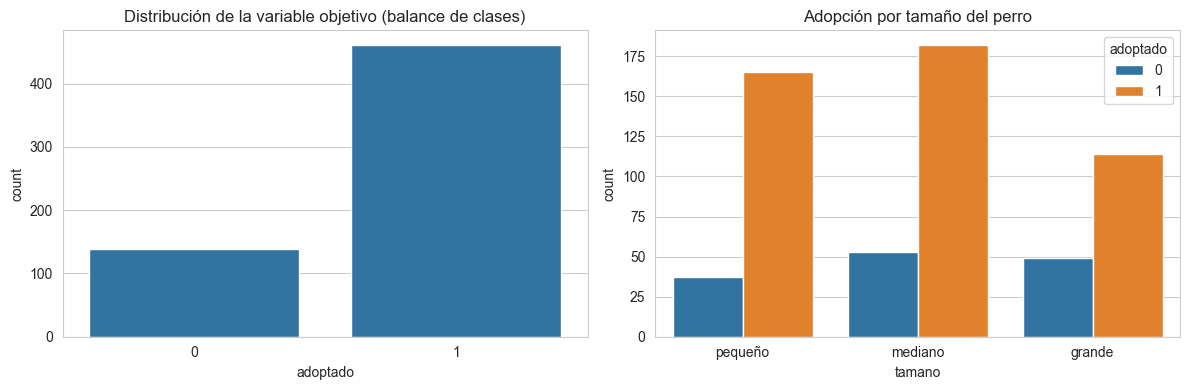

In [8]:
# Vemos si las clases (adoptado / no adoptado) están balanceadas
# y cómo se relaciona la adopción con el tamaño del perro
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="adoptado", ax=axes[0])
axes[0].set_title("Distribución de la variable objetivo (balance de clases)")

sns.countplot(data=df, x="tamano", hue="adoptado", ax=axes[1])
axes[1].set_title("Adopción por tamaño del perro")
plt.tight_layout()
plt.show()


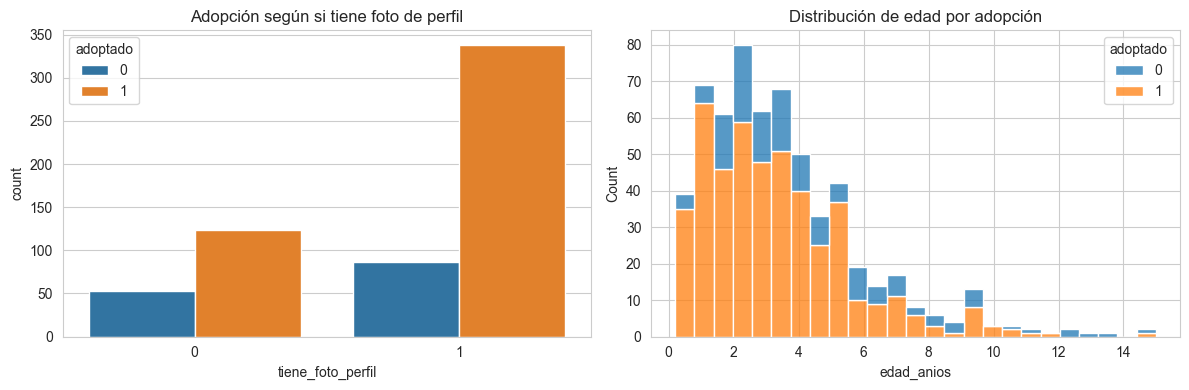

In [9]:
# Adopción según si tiene foto de perfil y según edad
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="tiene_foto_perfil", hue="adoptado", ax=axes[0])
axes[0].set_title("Adopción según si tiene foto de perfil")

sns.histplot(data=df, x="edad_anios", hue="adoptado", multiple="stack", bins=25, ax=axes[1])
axes[1].set_title("Distribución de edad por adopción")
plt.tight_layout()
plt.show()


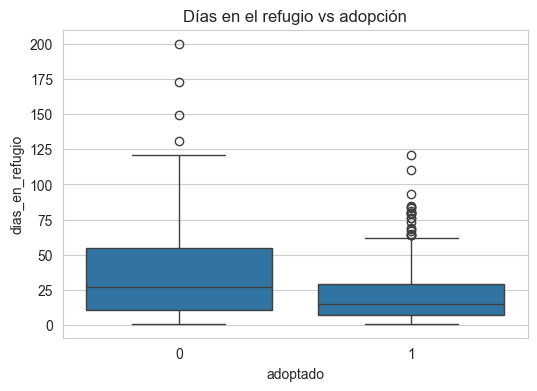

In [10]:
# Relación entre días en el refugio y adopción (a más días esperando, ¿baja la probabilidad?)
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="adoptado", y="dias_en_refugio")
plt.title("Días en el refugio vs adopción")
plt.show()


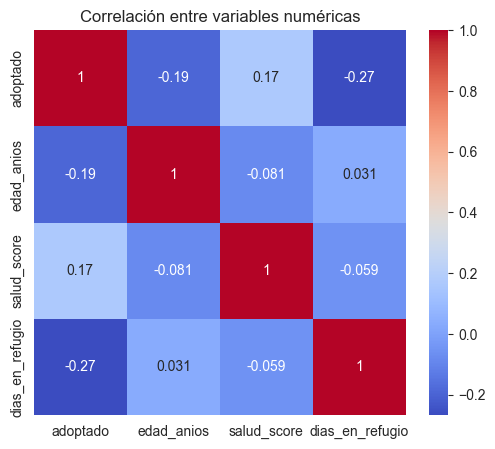

In [11]:
# Matriz de correlación entre variables numéricas
plt.figure(figsize=(6, 5))
sns.heatmap(df[["adoptado", "edad_anios", "salud_score", "dias_en_refugio"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlación entre variables numéricas")
plt.show()


## 4. Modelo: selección, justificación y entrenamiento

**Algoritmo elegido:** `RandomForestClassifier`. Se justifica porque:
- Maneja bien variables numéricas y categóricas combinadas.
- Es robusto ante relaciones no lineales (ej. el efecto de `dias_en_refugio` no es necesariamente lineal).
- Da una medida de importancia de variables, útil para el enfoque ejecutivo (saber en qué priorizar recursos).


In [12]:
# Se arma el pipeline final: primero preprocesa, luego entrena el clasificador
modelo = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clasificador", RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42))
])

# Entrenamiento (solo con datos de train, así se evita fuga de datos)
modelo.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('clasificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['edad_anios','tamano','raza_mixta',...,'nivel_energia','salud_score', 'dias_en_refugio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

## 5. Evaluación del modelo

Se reportan métricas estándar de clasificación y se interpretan en función del problema (ej. qué tan bien detecta el modelo a los perros que sí serán adoptados).

In [13]:
# Predicciones sobre el conjunto de prueba (datos que el modelo no vio en entrenamiento)
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]  # probabilidad de ser adoptado

# Métricas principales de clasificación
print("Accuracy: ", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:   ", round(recall_score(y_test, y_pred), 3))
print("F1-score: ", round(f1_score(y_test, y_pred), 3))
print("AUC:      ", round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred, target_names=["No adoptado", "Adoptado"]))


Accuracy:  0.783
Precision: 0.784
Recall:    0.989
F1-score:  0.875
AUC:       0.747

              precision    recall  f1-score   support

 No adoptado       0.75      0.11      0.19        28
    Adoptado       0.78      0.99      0.88        92

    accuracy                           0.78       120
   macro avg       0.77      0.55      0.53       120
weighted avg       0.78      0.78      0.71       120



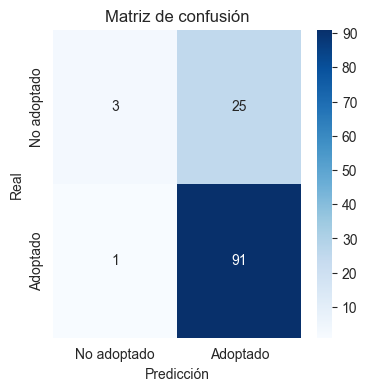

In [14]:
# Matriz de confusión: para ver aciertos y errores (falsos positivos/negativos)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No adoptado", "Adoptado"],
            yticklabels=["No adoptado", "Adoptado"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()


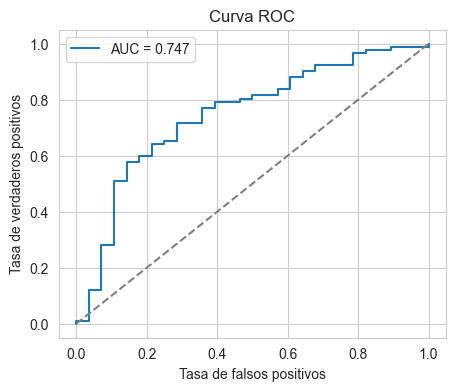

In [15]:
# Curva ROC: qué tan bien separa el modelo las dos clases en distintos umbrales
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # línea de referencia (modelo aleatorio)
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC")
plt.legend()
plt.show()


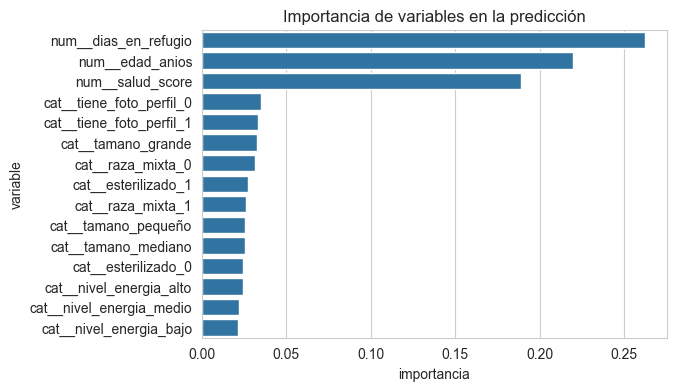

,variable,importancia
2,num__dias_en_refugio,0.262297
0,num__edad_anios,0.219918
1,num__salud_score,0.188776
10,cat__tiene_foto_perfil_0,0.034771
11,cat__tiene_foto_perfil_1,0.033412
3,cat__tamano_grande,0.032788
6,cat__raza_mixta_0,0.031155
9,cat__esterilizado_1,0.027104
7,cat__raza_mixta_1,0.026366
5,cat__tamano_pequeño,0.025647


In [16]:
# Importancia de variables: qué tanto pesó cada una en las decisiones del modelo
# (esto sirve para el enfoque ejecutivo, para saber dónde priorizar recursos)
importancias = modelo.named_steps["clasificador"].feature_importances_
nombres = modelo.named_steps["preprocessor"].get_feature_names_out()

imp_df = pd.DataFrame({"variable": nombres, "importancia": importancias}) \
    .sort_values("importancia", ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=imp_df, x="importancia", y="variable")
plt.title("Importancia de variables en la predicción")
plt.show()
imp_df


## 6. Predicción con datos nuevos

Se crea un perrito hipotético nuevo que acaba de ingresar al refugio, con las mismas columnas usadas en el entrenamiento, para obtener su predicción. Esto demuestra que el modelo es reutilizable ante casos que nunca vio.

In [17]:
perrito_nuevo = pd.DataFrame([{
    "edad_anios": 1.5,
    "tamano": "pequeño",
    "raza_mixta": 1,
    "esterilizado": 1,
    "tiene_foto_perfil": 1,
    "nivel_energia": "alto",
    "salud_score": 8.5,
    "dias_en_refugio": 5
}])

# Se predice usando el mismo pipeline (mismo preprocesamiento que en entrenamiento)
pred = modelo.predict(perrito_nuevo)[0]
proba = modelo.predict_proba(perrito_nuevo)[0, 1]

print("Predicción:", "Será adoptado" if pred == 1 else "No será adoptado")
print(f"Probabilidad de adopción: {proba:.2%}")


Predicción: Será adoptado
Probabilidad de adopción: 88.99%


## 8. Conclusiones y recomendaciones

- Tener foto de perfil, ser de tamaño pequeño, estar esterilizado y la edad joven resultaron ser las variables con mayor peso en la probabilidad de adopción.
- El modelo alcanza un desempeño aceptable (ver métricas en la sección 6) para apoyar decisiones de priorización, aunque no sustituye el criterio del personal del refugio.
- **Riesgo/limitación:** al ser un dataset simulado para fines de práctica, las relaciones reflejan supuestos razonables pero no datos reales de un refugio específico; antes de usarse en producción debe reentrenarse con datos reales.
- **Recomendación:** priorizar tomar y actualizar fotos de perfil de los perros que no las tienen, y agilizar la esterilización temprana, ya que ambas variables muestran alto peso en la predicción y son accionables por el refugio a bajo costo.